### LOADING AND IMPORTING

In [1]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, LSTM, Dropout, Layer
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import matplotlib.pyplot as plt
import os
import pandas as pd

PROCESSED_PATH = r'../../processed_data' 
MODEL_SAVE_PATH = r'./model_checkpoints'

if not os.path.exists(MODEL_SAVE_PATH):
    os.makedirs(MODEL_SAVE_PATH)

print("Loading FD004 Global Arrays...")
X_train = np.load(os.path.join(PROCESSED_PATH, 'X_train_FD004_global.npy'))
y_train = np.load(os.path.join(PROCESSED_PATH, 'y_train_FD004_global.npy'))
X_test = np.load(os.path.join(PROCESSED_PATH, 'X_test_FD004_global.npy'))
y_test = np.load(os.path.join(PROCESSED_PATH, 'y_test_FD004_global.npy'))

print(f"Train Shape: {X_train.shape}")
print(f"Test Shape: {X_test.shape}")

Loading FD004 Global Arrays...
Train Shape: (46309, 60, 24)
Test Shape: (248, 60, 24)


### ATTENTION LAYER 

In [2]:
class Attention(Layer):
    def __init__(self, **kwargs):
        super(Attention, self).__init__(**kwargs)
    def build(self, input_shape):
        self.W = self.add_weight(name='attention_weight', shape=(input_shape[-1], 1), initializer='random_normal', trainable=True)
        self.b = self.add_weight(name='attention_bias', shape=(input_shape[1], 1), initializer='zeros', trainable=True)
        super(Attention, self).build(input_shape)
    def call(self, x):
        e = tf.keras.backend.tanh(tf.keras.backend.dot(x, self.W) + self.b)
        a = tf.keras.backend.softmax(e, axis=1)
        output = x * a
        return tf.keras.backend.sum(output, axis=1)

### BUILDING MODEL

In [4]:
def build_model(input_shape):
    inputs = Input(shape=input_shape)
    x = LSTM(128, return_sequences=True, name='lstm_layer')(inputs)
    x = Dropout(0.3)(x)
    x = Attention(name='attention_layer')(x)
    x = Dense(64, activation='relu')(x)
    x = Dropout(0.3)(x)
    x = Dense(32, activation='relu')(x)
    outputs = Dense(1, activation='linear')(x)
    
    model = Model(inputs=inputs, outputs=outputs)
    return model

model = build_model((X_train.shape[1], X_train.shape[2]))
model.compile(optimizer=Adam(learning_rate=0.001, clipnorm=1.0), loss='mse', metrics=['mae'])
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 60, 24)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_layer (LSTM)                    │ (None, 60, 128)             │          78,336 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 60, 128)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ attention_layer (Attention)          │ (None, 128)                 │             188 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 88,893 (347.24 KB)

 Trainable params: 88,893 (347.24 KB)

 Non-trainable params: 0 (0.00 B)

### TRAINING MODEL

In [5]:
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=0.00001, verbose=1)
early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)

print("\nStarting FD004 Global Training...")
history = model.fit(
    X_train, y_train,
    validation_split=0.2, 
    epochs=80, 
    batch_size=200, 
    callbacks=[early_stop, reduce_lr],
    verbose=1
)


Starting FD004 Global Training...
Epoch 1/80
186/186 ━━━━━━━━━━━━━━━━━━━━ 73s 351ms/step - loss: 4638.7349 - mae: 56.8574 - val_loss: 1776.7739 - val_mae: 37.4433 - learning_rate: 0.0010
Epoch 2/80
186/186 ━━━━━━━━━━━━━━━━━━━━ 63s 338ms/step - loss: 1850.2058 - mae: 37.9974 - val_loss: 1767.6720 - val_mae: 37.6382 - learning_rate: 0.0010
Epoch 3/80
186/186 ━━━━━━━━━━━━━━━━━━━━ 67s 358ms/step - loss: 1835.7415 - mae: 37.9164 - val_loss: 1800.3500 - val_mae: 38.2000 - learning_rate: 0.0010
Epoch 4/80
186/186 ━━━━━━━━━━━━━━━━━━━━ 61s 327ms/step - loss: 1825.7117 - mae: 37.6701 - val_loss: 1847.6512 - val_mae: 38.6716 - learning_rate: 0.0010
Epoch 5/80
186/186 ━━━━━━━━━━━━━━━━━━━━ 62s 335ms/step - loss: 1737.1210 - mae: 36.5638 - val_loss: 1772.6143 - val_mae: 37.9225 - learning_rate: 0.0010
Epoch 6/80
186/186 ━━━━━━━━━━━━━━━━━━━━ 62s 334ms/step - loss: 1781.7010 - mae: 36.9170 - val_loss: 1544.6588 - val_mae: 35.1023 - learning_rate: 0.0010
Epoch 7/80
186/186 ━━━━━━━━━━━━━━━━━━━━ 62s 333

### SAVING

In [8]:
model_path = os.path.join(MODEL_SAVE_PATH, 'global_fd004.keras')
model.save(model_path)
print(f"\nModel saved to {model_path}")


Model saved to ./model_checkpoints\global_fd004.keras


### EVALUATING

In [7]:
print("\nEvaluating on Blind Test Set...")
predictions = model.predict(X_test, verbose=0)

final_rmse = np.sqrt(np.mean((predictions.flatten() - y_test) ** 2))

print("\n" + "="*50)
print(f"FD004 GLOBAL BASELINE RMSE: {final_rmse:.4f}")
print("="*50)


Evaluating on Blind Test Set...

FD004 GLOBAL BASELINE RMSE: 40.5655


### VISUALISING

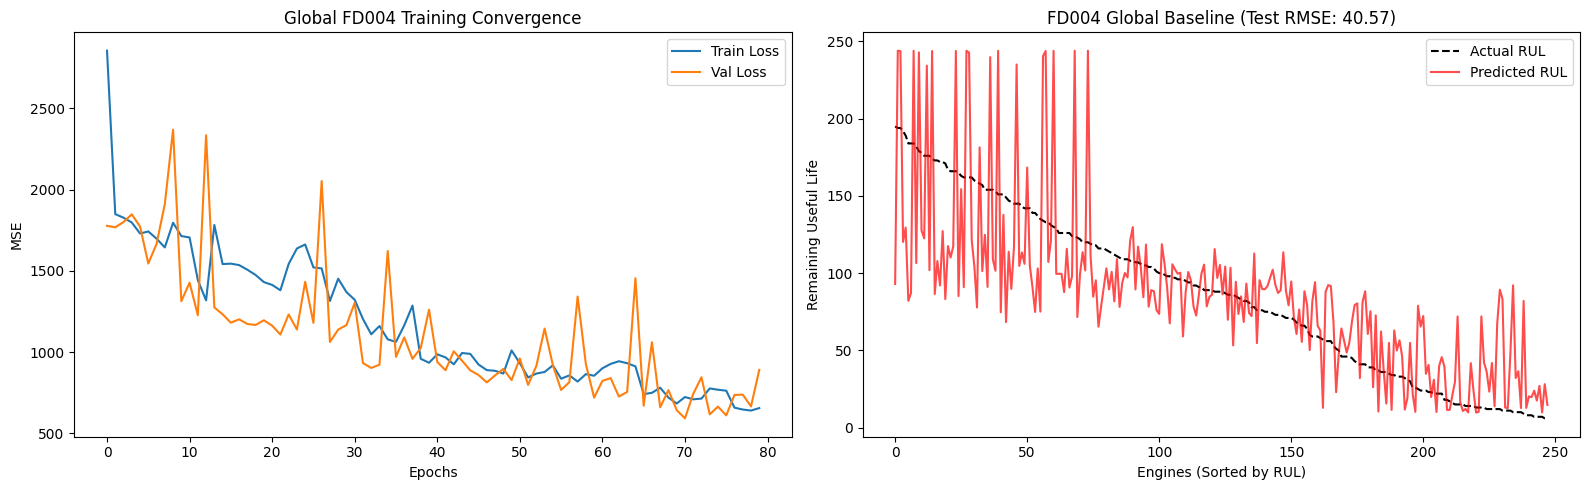

In [9]:
results_df = pd.DataFrame({'True': y_test, 'Pred': predictions.flatten()}).sort_values('True', ascending=False).reset_index(drop=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Loss Curve
axes[0].plot(history.history['loss'], label='Train Loss')
axes[0].plot(history.history['val_loss'], label='Val Loss')
axes[0].set_title('Global FD004 Training Convergence')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('MSE')
axes[0].legend()

# Predictions
axes[1].plot(results_df['True'], label='Actual RUL', color='black', linestyle='--')
axes[1].plot(results_df['Pred'], label='Predicted RUL', color='red', alpha=0.7)
axes[1].set_title(f'FD004 Global Baseline (Test RMSE: {final_rmse:.2f})')
axes[1].set_xlabel('Engines (Sorted by RUL)')
axes[1].set_ylabel('Remaining Useful Life')
axes[1].legend()

plt.tight_layout()
plt.show()